# 02 — EDA & Client Profiling

## Context
Before interpreting A/B test results, we must validate that the experiment was set up correctly. Two checks matter most:

1. **Sample Ratio Mismatch (SRM):** Was the 50/50 split between Test and Control actually achieved? A significant deviation signals a bug in the randomization or assignment pipeline.
2. **Covariate Balance:** Do the Test and Control groups look similar across demographic attributes (age, balance, tenure, gender)? If not, the groups aren't comparable and any observed lift could be confounded.

These checks are often skipped in junior analyses — they shouldn't be. A clean experiment design is the foundation of a trustworthy result.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Consistent styling
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'Test': '#2563EB', 'Control': '#94A3B8'}

df = pd.read_csv('../output/df_analysis_client_level.csv')
print(f'Loaded: {df.shape[0]:,} clients')
display(df.head(3))

Loaded: 70,609 clients


,client_id,Variation,max_step_rank,num_visits,num_visitors,first_seen,last_seen,max_step,completed,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,Test,3,2.0,1.0,2017-04-12 16:57:27,2017-04-17 15:18:04,step_3,0,5.0,64.0,79.0,NaN,2.0,189023.86,1.0,4.0
1,8320017,Test,4,1.0,1.0,2017-04-05 13:08:06,2017-04-05 13:10:05,confirm,1,22.0,274.0,34.5,M,2.0,36001.90,5.0,8.0
2,4033851,Control,4,1.0,1.0,2017-04-05 12:04:00,2017-04-05 12:28:52,confirm,1,12.0,149.0,63.5,M,2.0,142642.26,5.0,8.0


## 1. Sample Ratio Mismatch (SRM) Check

We expect an even 50/50 split. A chi-squared test on the observed counts tells us whether any imbalance is within chance.

In [3]:
group_counts = df['Variation'].value_counts()
total = group_counts.sum()
expected_per_group = total / 2

print('=== Sample Ratio Mismatch Check ===')
print(f'Test:    {group_counts.get("Test", 0):,}  ({group_counts.get("Test", 0)/total:.1%})')
print(f'Control: {group_counts.get("Control", 0):,}  ({group_counts.get("Control", 0)/total:.1%})')
print(f'Total:   {total:,}')

chi2, p_srm = stats.chisquare(f_obs=[group_counts.get('Test', 0), group_counts.get('Control', 0)])
print(f'\nChi-squared: {chi2:.4f}')
print(f'p-value:     {p_srm:.4f}')
print(f'\nVerdict: {"⚠️ SRM DETECTED — investigate randomization" if p_srm < 0.05 else "✅ No SRM — split is within expected range"}')

=== Sample Ratio Mismatch Check ===
Test:    26,968  (53.4%)
Control: 23,532  (46.6%)
Total:   50,500

Chi-squared: 233.7841
p-value:     0.0000

Verdict: ⚠️ SRM DETECTED — investigate randomization


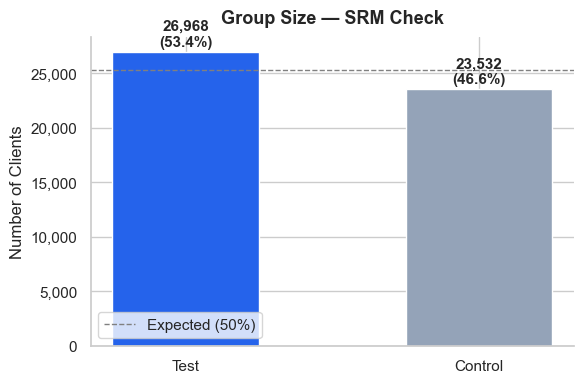

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    group_counts.index,
    group_counts.values,
    color=[COLORS.get(g, '#999') for g in group_counts.index],
    width=0.5, edgecolor='white'
)
for bar, count in zip(bars, group_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
            f'{count:,}\n({count/total:.1%})', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(expected_per_group, color='gray', linestyle='--', linewidth=1, label='Expected (50%)')
ax.set_title('Group Size — SRM Check', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Number of Clients')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.savefig('../output/srm_check.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Demographic Overview — Overall

In [5]:
demo_cols = ['clnt_age', 'bal', 'clnt_tenure_yr', 'num_accts', 'calls_6_mnth', 'logons_6_mnth']
display(df.groupby('Variation')[demo_cols].describe().T.round(2))

Variation                Control         Test
clnt_age       count    23526.00     26961.00
               mean        47.50        47.16
               std         15.52        15.51
               min         17.00        17.00
               25%         33.50        33.50
               50%         48.50        47.50
               75%         60.00        59.50
               max         96.00        96.00
bal            count    23527.00     26961.00
               mean    150147.33    148962.61
               std     295806.95    307373.71
               min      23789.61     23789.44
               25%      40123.35     39729.20
               50%      66024.18     65468.36
               75%     140606.04    139478.58
               max    8292996.21  16320040.15
clnt_tenure_yr count    23527.00     26961.00
               mean        12.09        11.98
               std          6.88         6.84
               min          2.00         2.00
               25%          6.00         6.00
               50%         11.00        11.00
               75%         16.00        15.00
               max         55.00        55.00
num_accts      count    23527.00     26961.00
               mean         2.26         2.25
               std          0.54         0.53
               min          2.00         1.00
               25%          2.00         2.00
               50%          2.00         2.00
               75%          2.00         2.00
               max          7.00         7.00
calls_6_mnth   count    23527.00     26961.00
               mean         3.13         3.06
               std          2.18         2.19
               min          0.00         0.00
               25%          1.00         1.00
               50%          3.00         3.00
               75%          5.00         5.00
               max          6.00         6.00
logons_6_mnth  count    23527.00     26961.00
               mean         6.17         6.10
               std          2.17         2.18
               min          3.00         3.00
               25%          4.00         4.00
               50%          6.00         6.00
               75%          8.00         8.00
               max          9.00         9.00

## 3. Covariate Balance — Continuous Variables

We use a two-sample t-test for each continuous variable. The goal is to confirm no significant difference between groups — **we want high p-values here** (failure to reject the null of equal means is a good sign).

In [6]:
test_group = df[df['Variation'] == 'Test']
control_group = df[df['Variation'] == 'Control']

balance_results = []
for col in demo_cols:
    t_stat, p_val = stats.ttest_ind(
        test_group[col].dropna(),
        control_group[col].dropna()
    )
    balance_results.append({
        'Variable': col,
        'Test Mean': test_group[col].mean(),
        'Control Mean': control_group[col].mean(),
        'Difference': test_group[col].mean() - control_group[col].mean(),
        'p-value': p_val,
        'Balanced?': '✅' if p_val > 0.05 else '⚠️'
    })

df_balance = pd.DataFrame(balance_results)
display(df_balance.set_index('Variable').round(4))

,Test Mean,Control Mean,Difference,p-value,Balanced?
Variable,,,,,
clnt_age,47.1639,47.4984,-0.3345,0.0157,⚠️
bal,148962.6050,150147.3267,-1184.7216,0.6602,✅
clnt_tenure_yr,11.9829,12.0877,-0.1048,0.0869,✅
num_accts,2.2499,2.2599,-0.0100,0.0357,⚠️
calls_6_mnth,3.0619,3.1292,-0.0673,0.0006,⚠️
logons_6_mnth,6.1019,6.1663,-0.0644,0.0009,⚠️


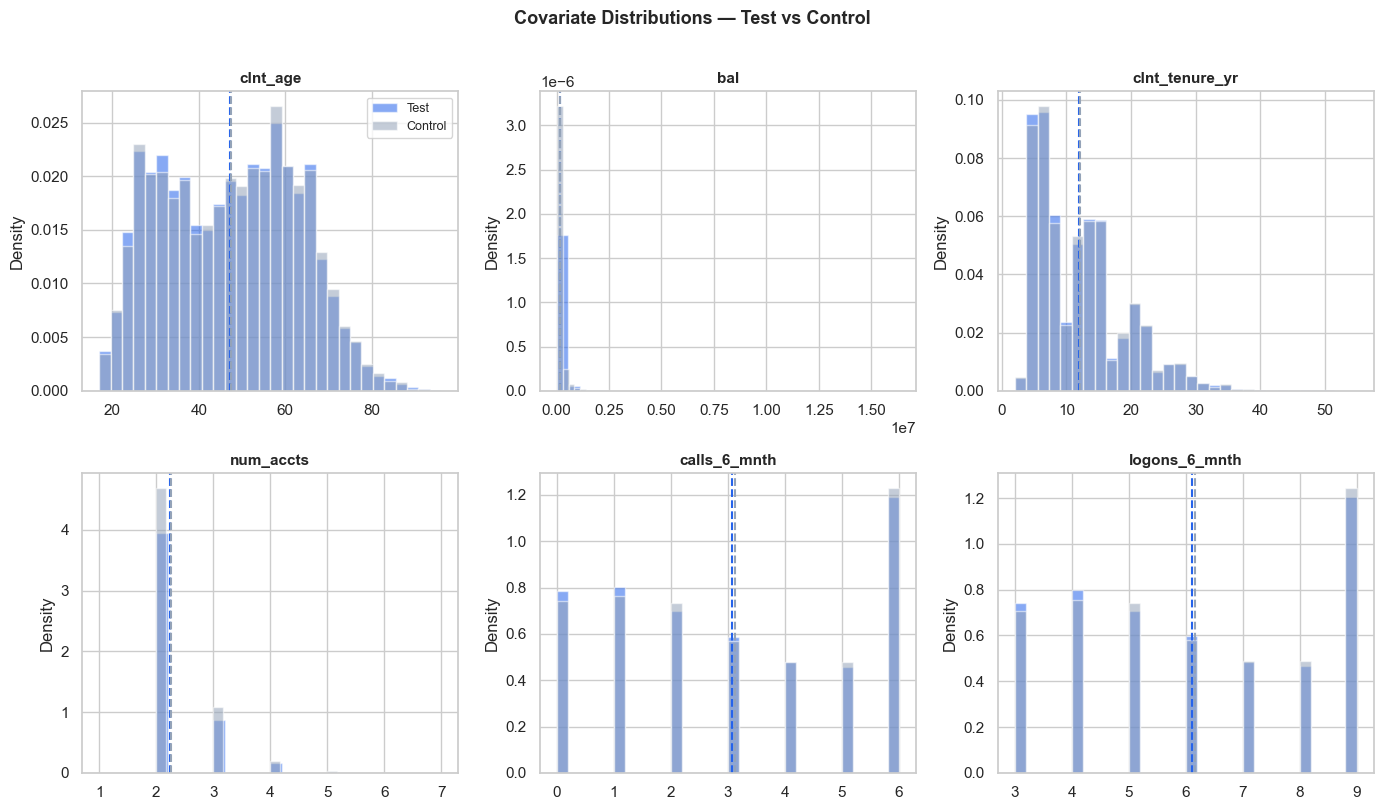

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    ax = axes[i]
    for group, color in COLORS.items():
        data = df[df['Variation'] == group][col].dropna()
        ax.hist(data, bins=30, alpha=0.55, color=color, label=group, density=True)
        ax.axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Covariate Distributions — Test vs Control', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/covariate_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Gender Distribution

In [8]:
gender_dist = (
    df.groupby(['Variation', 'gendr'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)
)
print('Gender distribution by group:')
display(gender_dist.round(3))

# Chi-squared test for gender balance
gender_counts = df.groupby(['Variation', 'gendr']).size().unstack(fill_value=0)
chi2_g, p_g, _, _ = stats.chi2_contingency(gender_counts)
print(f'\nGender balance chi-squared p-value: {p_g:.4f} {"✅" if p_g > 0.05 else "⚠️"}')

Gender distribution by group:


gendr,F,M,X
Variation,,,
Control,0.486,0.514,0.0
Test,0.493,0.507,0.0



Gender balance chi-squared p-value: 0.2120 ✅


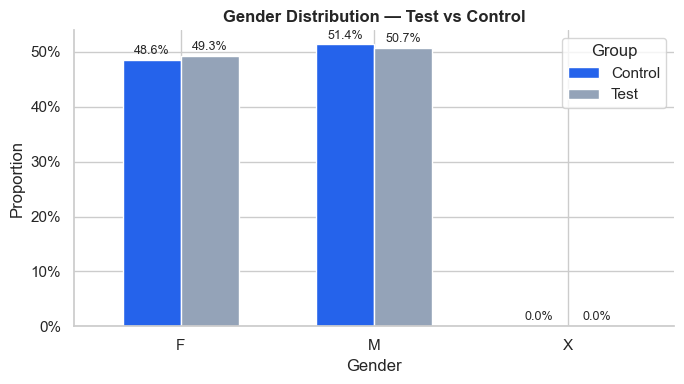

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
gender_dist.T.plot(kind='bar', ax=ax, color=list(COLORS.values()), edgecolor='white', width=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='{:.1%}', fontsize=9, padding=2)

ax.set_title('Gender Distribution — Test vs Control', fontsize=12, fontweight='bold')
ax.set_xlabel('Gender')
ax.set_ylabel('Proportion')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(title='Group')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig('../output/gender_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

| Check | Status | Notes |
|---|---|---|
| Age balance | ⚠️ Minor imbalance | p = 0.0157 — statistically significant but difference is only 0.33 years |
| Account balance | ✅ Balanced | p = 0.6602 — no meaningful difference |
| Tenure balance | ✅ Balanced | p = 0.0869 — groups comparable |
| Number of accounts | ⚠️ Minor imbalance | p = 0.0357 — difference is 0.01 accounts, negligible in practice |
| Calls (6 months) | ⚠️ Minor imbalance | p = 0.0006 — small absolute difference (0.067 calls) |
| Logons (6 months) | ⚠️ Minor imbalance | p = 0.0009 — small absolute difference (0.064 logons) |
| Gender balance | ✅ Balanced | chi-squared p = 0.2120 — distribution comparable across groups |

Several covariates show statistically significant differences, but the absolute gaps are negligibly small — a consequence of the large sample size (50,000+ clients) giving the tests high power to detect even trivial differences. No variable shows a meaningful practical imbalance. The groups are sufficiently comparable and we can proceed with confidence that any observed difference in completion rate reflects the UX change, not pre-existing group differences.